//TODO: Add Diane's physical guards in HBVTransition, then you should also be able to set Q=0 for S1_prev

//TODO: Gain of $K = U\text{pinv}(V)$ vs $UV^T [VV^T + R]^{-1}$

//TODO add version of EnsembleKalmanFilter class that has multiplicative and additive input uncertainties, maybe define new KF class that inherits everything from the old one except new prediction function that can handle input errors

After that this should exactly reproduce our results from first project

In [3]:
#!git clone https://github.com/Felix-Schwer/rainfall_kf.git
%cd /content/rainfall_kf
#!git pull origin main
#!pip uninstall -y rainfall_kf
!pip install -e .

/content/rainfall_kf
Obtaining file:///content/rainfall_kf
  Preparing metadata (setup.py) ... done
  Running setup.py develop for rainfall_kf


In [5]:
import numpy as np

from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.examples.hbvedu_read import read_hbv_initial, read_hbv_inputs, read_hbv_params, read_hbv_qobs
from rainfall_kf.models.hbvedu import HBVObservation, HBVTransition

np.random.seed(1)

N_STATES = 5
N_OBS = 1
N_ENS = 100

Qassumed = np.diag([2, 2, 0.5, 0.5, 0])
Rassumed = np.diag([0.25])

params = read_hbv_params()
inputs_k = read_hbv_inputs()
observations_k = read_hbv_qobs()

iv_values = np.loadtxt("/content/rainfall_kf/rainfall_kf/examples/HBV_EDU/IV.txt", dtype=float, usecols=(1,))
catchment_area = iv_values[0]
observations_mm_day = observations_k * (24 * 3600.0) / (catchment_area * 1000.0)

x0 = read_hbv_initial()
k_steps = inputs_k.shape[1]
times = np.arange(k_steps)

initial_ensemble = x0 + np.linalg.cholesky(Qassumed).T @ np.random.randn(N_STATES, N_ENS)

In [6]:
enkf = EnsembleKalmanFilter(
    TransitionEquation=lambda states, inputs: HBVTransition(states, inputs, params),
    ObservationEquation=lambda states: HBVObservation(states, params),
    Q=Qassumed,
    R=Rassumed,
    addGaussInputSig=np.array([0.2, 0., 0., 0.]),
    mulLognormInputSig=np.array([0., 0.2, 0., 0.])
)

result = enkf.run(initial_ensemble=initial_ensemble, times=times, inputs=inputs_k, observations=observations_mm_day)

Text(0.5, 0, 'Time step')

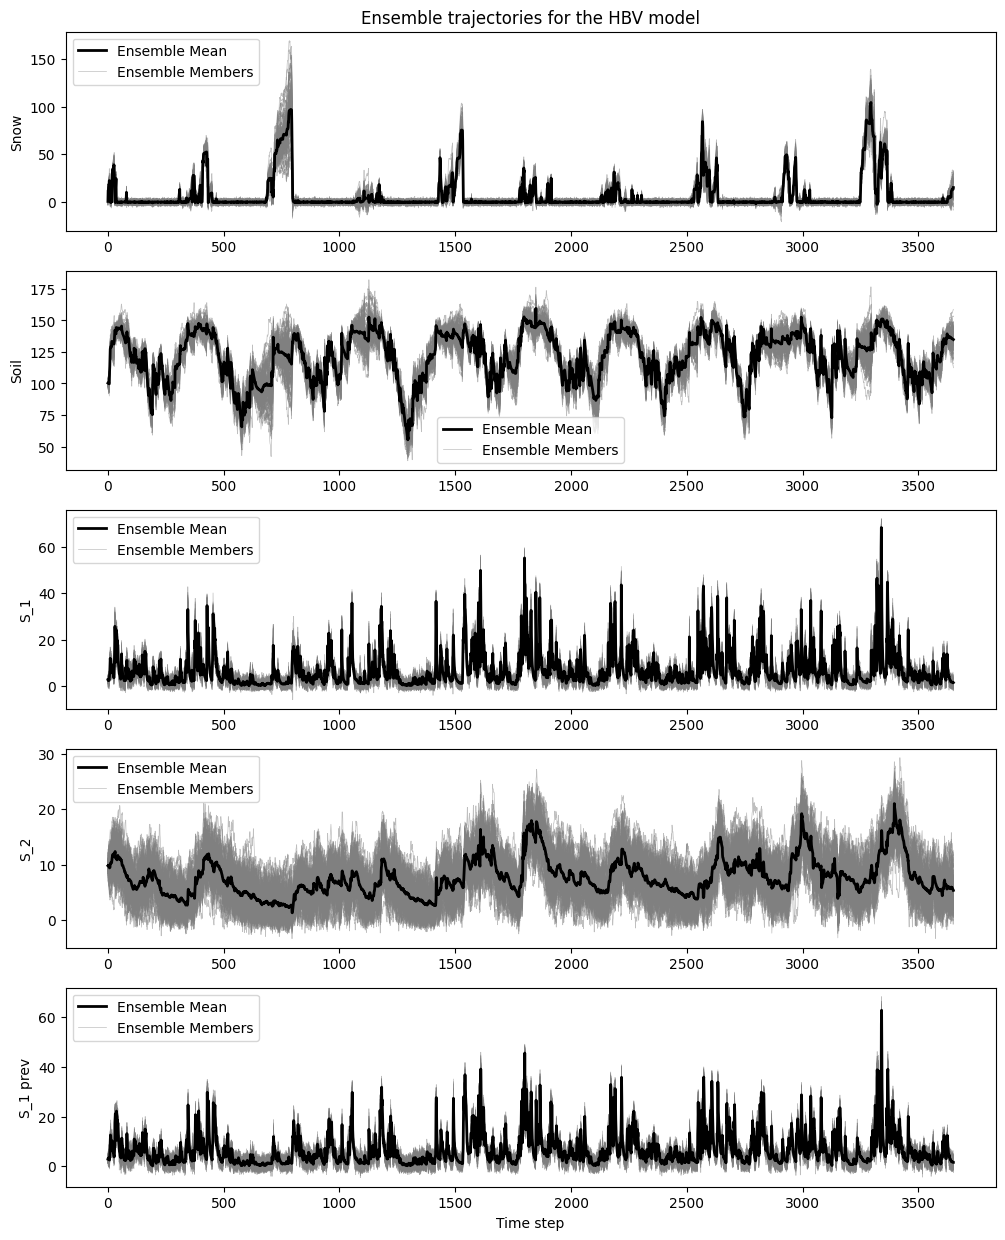

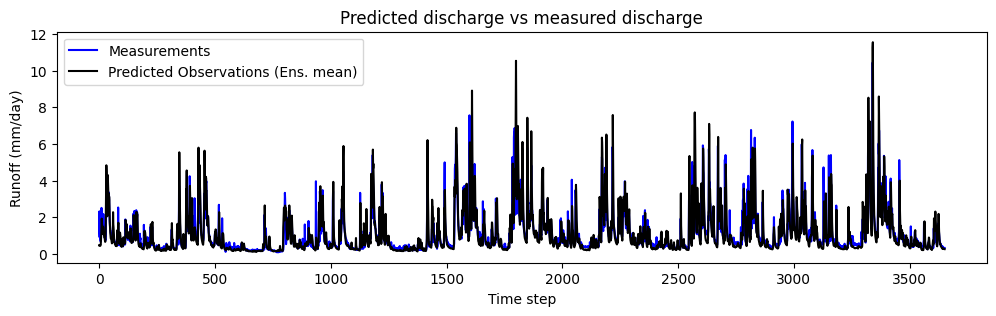

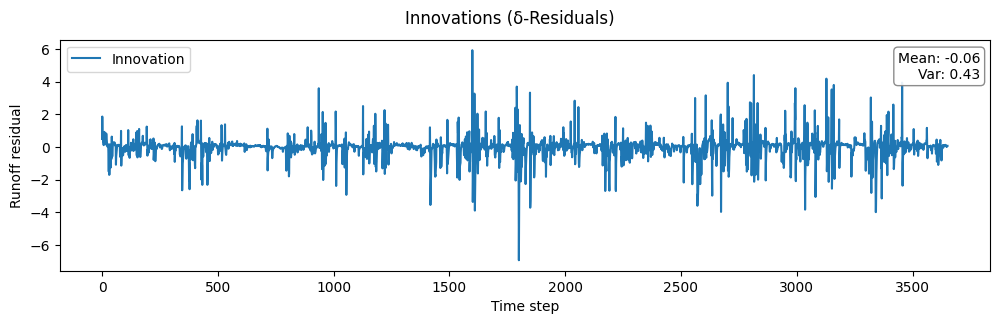

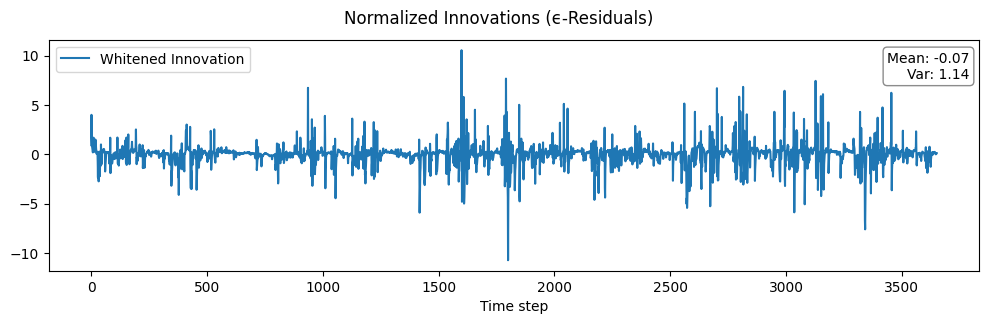

In [7]:
fig = result.plot_ensembles()
axes = fig.get_axes()
axes[0].set_title("Ensemble trajectories for the HBV model")
axes[0].set_ylabel("Snow")
axes[1].set_ylabel("Soil")
axes[2].set_ylabel("S_1")
axes[3].set_ylabel("S_2")
axes[4].set_ylabel("S_1 prev")
axes[4].set_xlabel("Time step")

fig = result.plot_observations()
ax = fig.get_axes()[0]
ax.set_title("Predicted discharge vs measured discharge")
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff (mm/day)")

fig = result.plot_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff residual")

fig = result.plot_whitened_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")